# Library

In [1]:
import sys, warnings
sys.path.append('..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from src.preprocessing import (
    load_data,
    check_info,
    check_describe,
    drop_irrelevant_columns,
    handle_missing_values,
    handle_duplicate_rows,
    iqr_capping,
    drop_redundant_features,
    drop_low_relevance_categoricals,
    run_chi2_test,
    full_preprocessing_pipeline,
)

# Load Data

In [2]:
df_all = load_data('D:\Dibimbing.Id\Supply Chain\dataset\DataCoSupplyChainDataset.csv')
df = df_all.copy()
df.head()


Dataset berjumlah 180519 baris dan 53 kolom


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
# Informasi Data
df = check_info(df)

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [4]:
# Analisis Statistik
df = check_describe(df)

       Days for shipping (real)  Days for shipment (scheduled)  \
count             180519.000000                  180519.000000   
mean                   3.497654                       2.931847   
std                    1.623722                       1.374449   
min                    0.000000                       0.000000   
25%                    2.000000                       2.000000   
50%                    3.000000                       4.000000   
75%                    5.000000                       4.000000   
max                    6.000000                       4.000000   

       Benefit per order  Sales per customer  Late_delivery_risk  \
count      180519.000000       180519.000000       180519.000000   
mean           21.974989          183.107609            0.548291   
std           104.433526          120.043670            0.497664   
min         -4274.979980            7.490000            0.000000   
25%             7.000000          104.379997            0.000000 

# Drop Kolom tidak relevan

In [5]:
df = drop_irrelevant_columns(df)

Kolom yang telah dihapus (22): ['Delivery Status', 'shipping date (DateOrders)', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Street', 'Customer Id', 'Order Customer Id', 'Order Id', 'Order Item Id', 'Order Item Cardprod Id', 'Product Card Id', 'Product Category Id', 'Category Id', 'Department Id', 'Product Image', 'Customer Zipcode', 'Latitude', 'Longitude', 'Product Description', 'Order Zipcode']


# Missing Value

In [6]:
df = handle_missing_values(df)

Tidak ada missing values.

Kolom yang memiliki missing value lebih dari 50%: []
Jumlah kolom sebelum didrop: 31
Jumlah kolom setelah didrop: 31


# Duplicates

In [7]:
df = handle_duplicate_rows(df)

Tidak ada data yang duplicates.


# IQR

### IQR Capping (Winsorization) ###
Kolom                                   Before      After
------------------------------------------------------------
Days for shipping (real)                     0          0
Days for shipment (scheduled)                0          0
Benefit per order                       18,942          0
Sales per customer                       1,943          0
Late_delivery_risk                           0          0
Order Item Discount                      7,537          0
Order Item Discount Rate                     0          0
Order Item Product Price                 2,048          0
Order Item Profit Ratio                 17,300          0
Order Item Quantity                          0          0
Sales                                      488          0
Order Item Total                         1,943          0
Order Profit Per Order                  18,942          0
Product Price                            2,048          0
Product Status                   

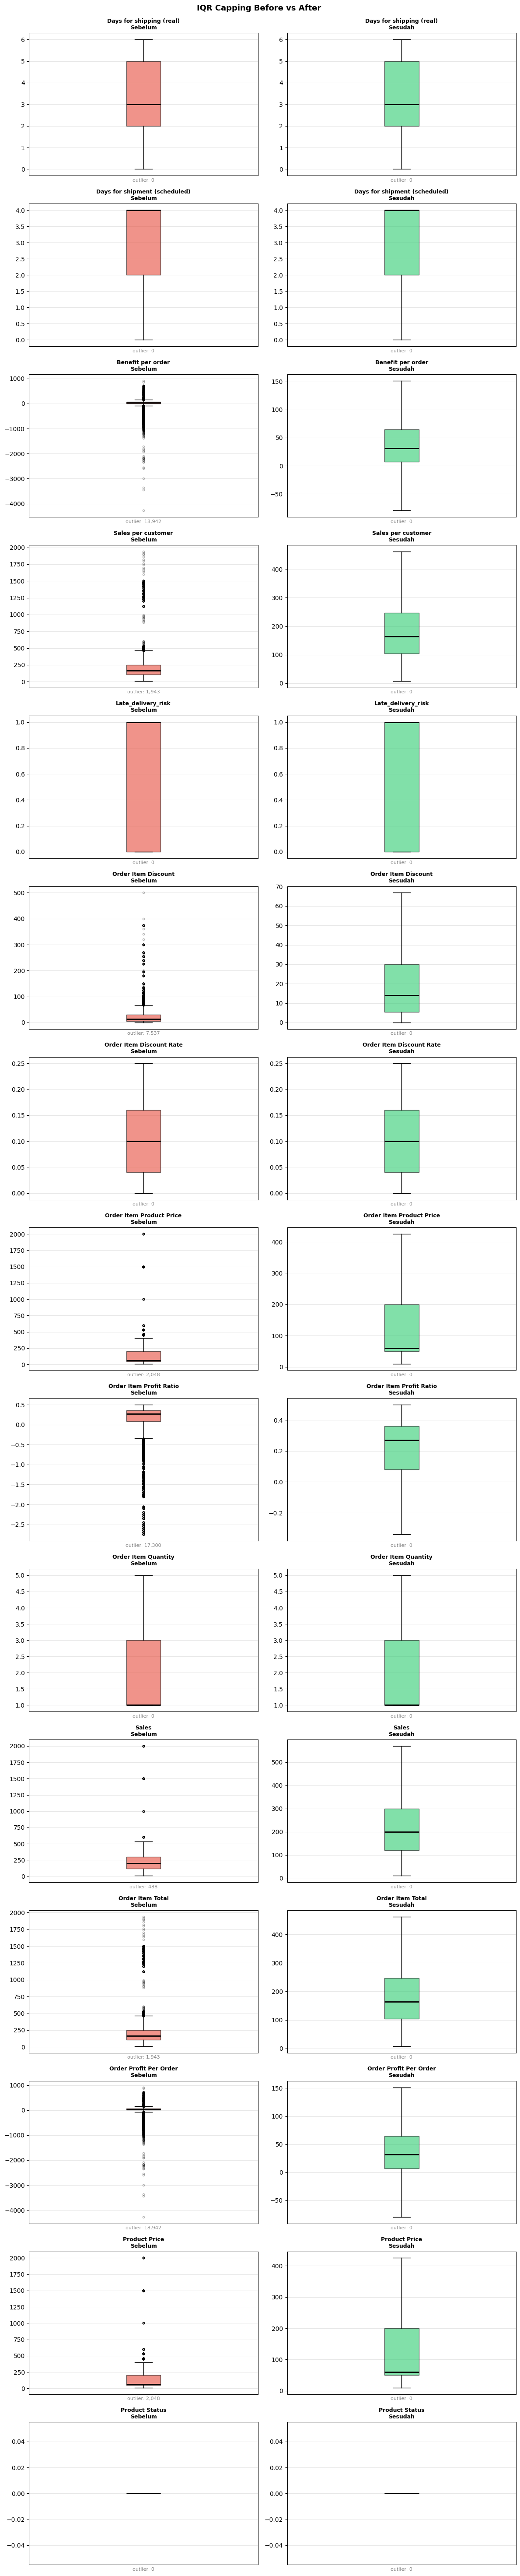

In [8]:
# visualisasi outlier sebelum dan sesudah IQR
df_before = df.copy()
num_cols = df_before.select_dtypes(include=['float64', 'int64']).columns.tolist()
df_after  = iqr_capping(df, num_cols)

# visualisasi
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    for j, (data, label, color) in enumerate([
        (df_before[col], 'Sebelum', '#e74c3c'),
        (df_after[col],  'Sesudah', '#2ecc71'),
    ]):
        ax = axes[i][j]
        ax.boxplot(data.dropna(), patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.6),
                   medianprops=dict(color='black', linewidth=2),
                   flierprops=dict(marker='.', color=color, alpha=0.3))
        ax.set_title(f'{col}\n{label}', fontsize=9, fontweight='bold')
        ax.set_xticks([])
        ax.grid(axis='y', alpha=0.3)

        # info outlier
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR    = Q3 - Q1
        n_out  = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
        ax.set_xlabel(f'outlier: {n_out:,}', fontsize=8, color='gray')

plt.suptitle('IQR Capping Before vs After \n\n\n\n\n',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Heatmap

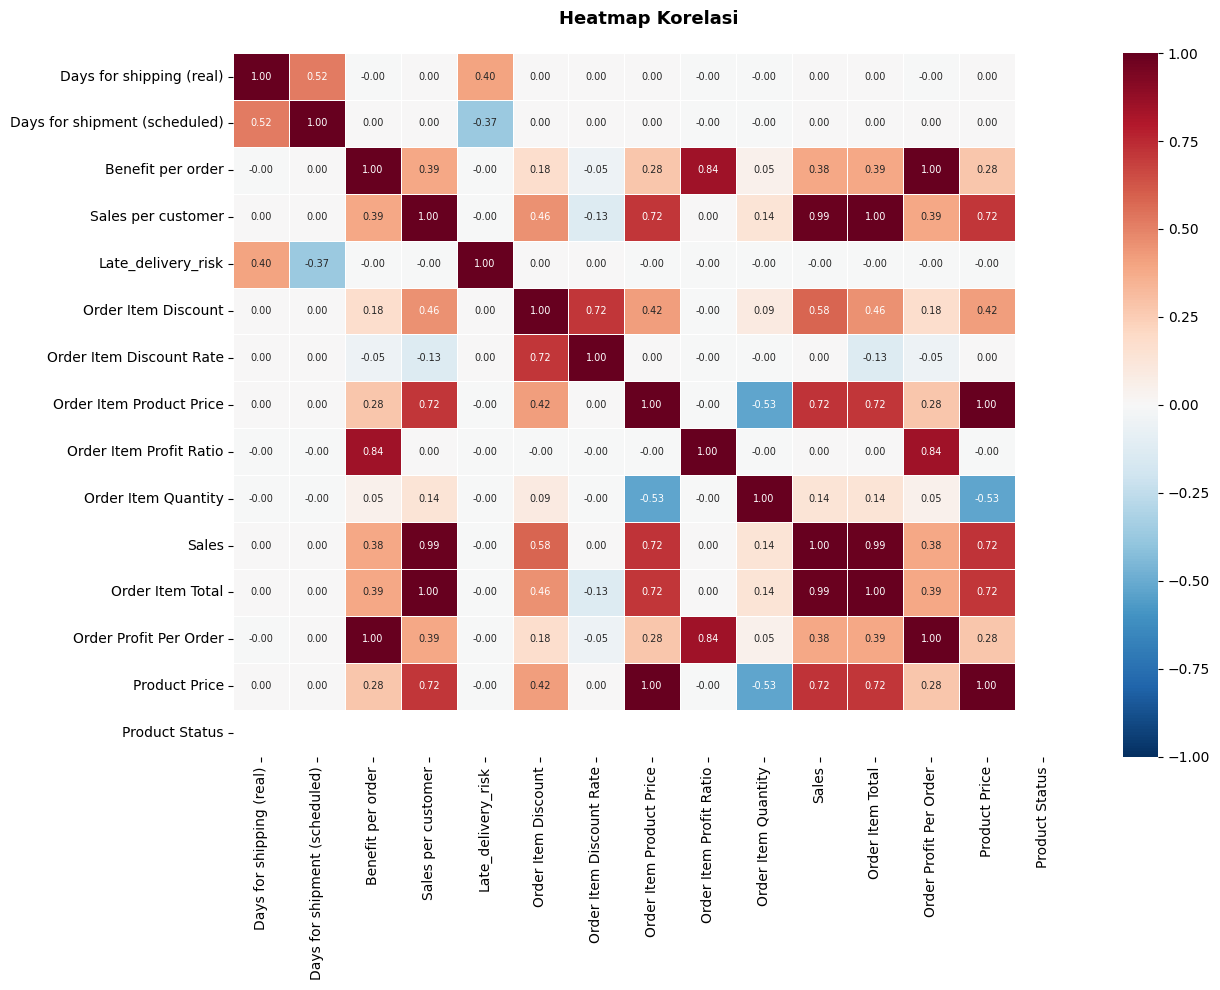

In [9]:
# visualisasi heatmap
num_cols = df_after.select_dtypes(include=['float64', 'int64']).columns.tolist()
corr = df_after[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    corr,
    annot=True,          # tampilkan angka korelasi
    fmt='.2f',           # 2 desimal
    cmap='RdBu_r',       # merah = negatif, biru = positif
    center=0,            # tengah di angka 0
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)

ax.set_title('Heatmap Korelasi \n', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# cari yang punya korelasi tinggi
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.95:
            high_corr.append({
                'Fitur A' : corr.columns[i],
                'Fitur B' : corr.columns[j],
                'Korelasi': round(val, 4)
            })

if high_corr:
    print('Pasangan korelasi tinggi (|r| > 0.95 ):')
    print(pd.DataFrame(high_corr).sort_values('Korelasi', ascending=False).to_string(index=False))
else:
    print('Tidak ada multikolinearitas ekstrem.')

Pasangan korelasi tinggi (|r| > 0.95 ):
                 Fitur A                Fitur B  Korelasi
       Benefit per order Order Profit Per Order    1.0000
      Sales per customer       Order Item Total    1.0000
Order Item Product Price          Product Price    1.0000
      Sales per customer                  Sales    0.9879
                   Sales       Order Item Total    0.9879


In [11]:
# hapus salah satu kolom yang memiliki korelasi tinggi
# dihapus karena memiliki multikolinearitas, menghindari informasi duplikat
df = drop_redundant_features(df)

Fitur redundan yang didrop: ['Order Profit Per Order', 'Order Item Product Price', 'Order Item Total']


# Chi-Square

In [12]:
sig_cat = run_chi2_test(df, target='Late_delivery_risk')


Fitur Kategorik                                  Chi2      p-value   Signifikan
--------------------------------------------------------------------------------
Type                                          1103.92       0.0000           Ya
Category Name                                   42.89       0.7180        Tidak
Customer City                                 1879.54       0.0000           Ya
Customer Country                                 0.19       0.6609        Tidak
Customer Segment                                 1.02       0.5991        Tidak
Customer State                                 101.08       0.0000           Ya
Department Name                                  6.67       0.7565        Tidak
Market                                           8.65       0.0704        Tidak
Order City                                   14195.30       0.0000           Ya
Order Country                                  580.04       0.0000           Ya
order date (DateOrders)               

In [13]:
# hapus kolom yang memiliki p-value > 0.05
# dihapus karena tidak memiliki hubungan dengan target
df = drop_low_relevance_categoricals(df)

Kolom kategorik yang didrop (10): ['Category Name', 'Customer Country', 'Customer Segment', 'Department Name', 'Market', 'Order City', 'Order State', 'order date (DateOrders)', 'Order Status', 'Order Country']


In [14]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Customer City', 'Customer State', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Region', 'Product Name', 'Product Price', 'Product Status', 'Shipping Mode']
